# 🏦 Bank Customer Churn Analysis

## Project Overview

For this project, I analyzed customer data from a bank to understand what drives customer churn and to identify customers who are most likely to leave. The dataset was sourced from Kaggle's Churn Modelling dataset and contains information on 10,000 customers across France, Germany, and Spain.

## Dataset Highlights

* 10,000 customer records
* Customers from France, Germany, and Spain
* 14 features including age, balance, credit score, estimated salary, and activity status

## Key Insights

After exploring the data, a few interesting patterns stood out:

* Around **20% of customers churned**, meaning roughly 1 in every 5 customers left the bank.
* Customers in **Germany had the highest churn rate**, despite France having the largest customer base.
* Customers aged **45–50 were more likely to churn** compared to other age groups.
* Customers with **higher account balances showed a greater tendency to leave**, which could indicate they are being attracted by competing banks.
* **Inactive customers churned significantly more** than active customers, highlighting customer engagement as an important factor in retention.

## Predictive Modelling

To predict customer churn, I built a **Decision Tree Classifier** using Scikit-learn.

### Model Performance

* Accuracy: **78.2%**
* Precision: **88%** for identifying loyal customers

The model showed a strong ability to identify customers who are likely to stay with the bank and provides a good foundation for developing customer retention strategies.

## Tools & Technologies
Python, Pandas, Seaborn, Matplotlib, Scikit-learn

### PROJECT STARTS HERE

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\freke\Churn_Modelling.csv")
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


checking for missing values and data types

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

We are working with a clean data, yay

In [ ]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

We can see that almost 8k stayed and 2k left

In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis= 1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


We are dropping those three columns because we don't need them

In [ ]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Now, we want to know how many customers have Left vs Stayed?

Chart 1: How many Customers Stayed vs Left?

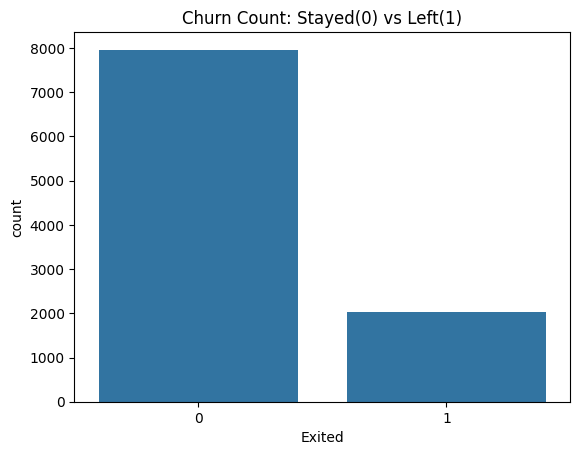

In [ ]:
sns.countplot(x='Exited', data = df)
plt.title('Churn Count: Stayed(0) vs Left(1)')
plt.show()

Chart 2: Does Geography affect the Churn?

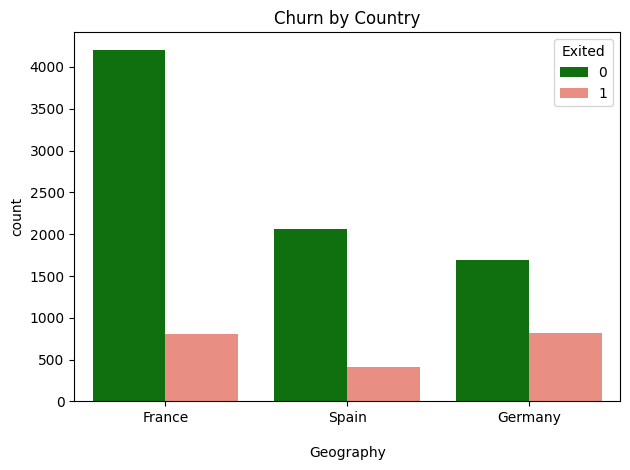

In [ ]:
sns.countplot(x= 'Geography', hue ='Exited', data = df, palette= ['green', 'salmon'])
plt.title('Churn by Country')
plt.xlabel('Geography', labelpad=15)  #i added a space between the labels and the title9
plt.tight_layout()
plt.show()

Chart 3: Does Age have an effect?

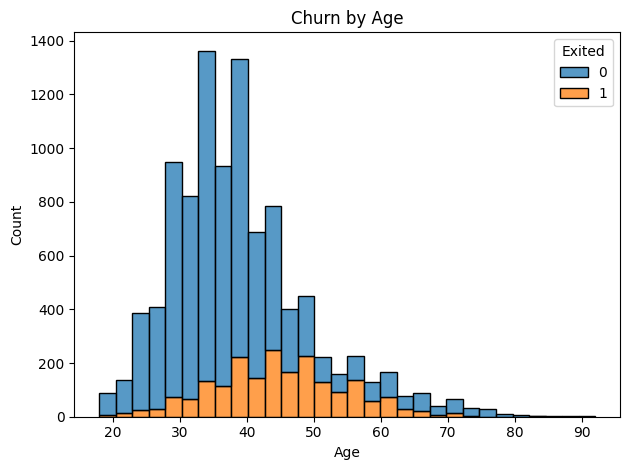

In [ ]:
sns.histplot(data = df, x = 'Age', hue = 'Exited', bins = 30, multiple= 'stack')
plt.title('Churn by Age')
plt.tight_layout()
plt.show()

From the graph -  Middle-aged customers (45-50) are the most likely to leave the bank.

Chart 4: Balance vs Churn

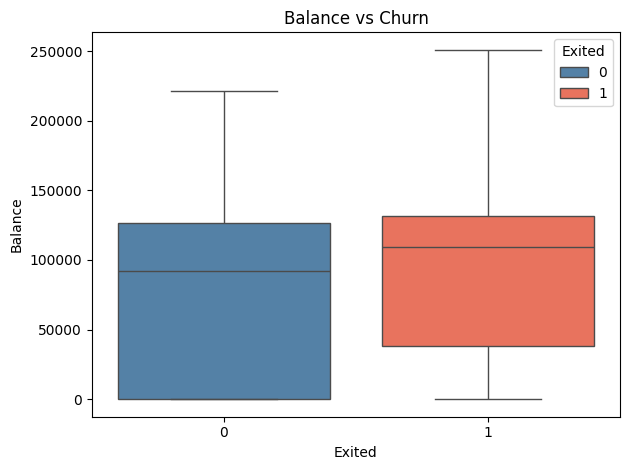

In [ ]:
sns.boxplot(x= 'Exited', y= 'Balance', data= df, hue='Exited', palette= ['Steelblue', 'Tomato'])
plt.title('Balance vs Churn')
plt.tight_layout()
plt.show()

Chart 5: Active Members vs Churn

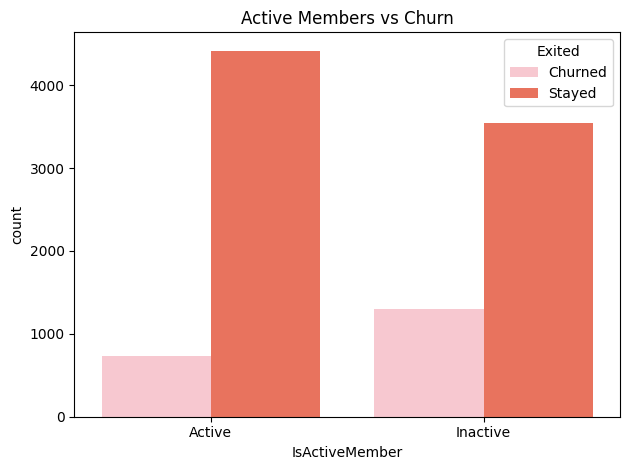

In [ ]:
df['IsActiveMember'] = df['IsActiveMember'].map({0: 'Inactive', 1: 'Active'})
df['Exited'] = df['Exited'].map({0: 'Stayed', 1: 'Churned'})

sns.countplot(x= 'IsActiveMember', hue= 'Exited', data= df, palette=['pink', 'tomato'])
plt.title('Active Members vs Churn')
plt.tight_layout()
plt.show()

This shows that inactive members churn more

In [ ]:
df['Exited'] = df['Exited'].map({'Stayed': 0, 'Churned': 1})

In [ ]:
df['IsActiveMember'] = df['IsActiveMember'].map({'Inactive': 0, 'Active': 1})

Reverting back for our prediction Model.

##### PREDICTION MODEL

In [ ]:
from sklearn.preprocessing import LabelEncoder

#I want to convert Geography and Gender from text to numbers
le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender']= le.fit_transform(df['Gender'])

In [ ]:
X= df.drop('Exited', axis=1)
y= df['Exited']

dropping the exited column in X, so we can check it later in y

We'll be training with 80% of the data, and testing with 20%

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(8000, 10)
(2000, 10)


In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


#### Training the Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model has been trained Successfully!!")

Model has been trained Successfully!!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.782
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.52      0.49       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.80      0.78      0.79      2000

